In [139]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose

In [140]:
data_path = os.path.abspath('c:\\Users\\Administrator\\Documents\\GitHub\\PrinciplesOfDataScience_Group2\\data\\time_series_data.csv') 
df = pd.read_csv(data_path)
# df = pd.read_csv('c:\\Users\\Administrator\\Documents\\GitHub\\PrinciplesOfDataScience_Group2\\data\\time_series_data.csv')
df.head()

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
0,1,197,66,266,113,2,1,18
1,2,153,44,264,74,1,2,21
2,3,128,55,317,116,0,1,19
3,4,133,57,390,70,0,2,17
4,5,120,47,440,141,1,1,18


In [6]:
df.tail()

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
95,96,174,226,975,94,0,1,2
96,97,158,201,1141,91,0,2,3
97,98,145,217,881,46,4,1,3
98,99,161,249,741,70,0,1,7
99,100,160,331,854,75,0,1,5


In [7]:
df.describe()

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
count,100.000000,100.000000,100.000000,100.0000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,148.370000,153.440000,631.5800,80.120000,0.550000,1.470000,13.020000
std,29.011492,18.061989,68.164288,202.8871,36.780891,1.225775,0.501614,5.915192
min,1.000000,107.000000,42.000000,203.0000,11.000000,0.000000,1.000000,2.000000
25%,25.750000,134.000000,95.500000,491.7500,55.750000,0.000000,1.000000,9.000000
50%,50.500000,151.000000,155.500000,611.0000,70.000000,0.000000,1.000000,13.000000
75%,75.250000,160.000000,200.250000,770.5000,100.250000,0.000000,2.000000,17.000000
max,100.000000,197.000000,331.000000,1141.0000,194.000000,5.000000,2.000000,26.000000


In [344]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   t            100 non-null    int64
 1   ProductP1    100 non-null    int64
 2   ProductP2    100 non-null    int64
 3   ProductP3    100 non-null    int64
 4   ProductP4    100 non-null    int64
 5   ProductP5    100 non-null    int64
 6   price        100 non-null    int64
 7   temperature  100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB


In [141]:
# Separate weekly and daily products
weekly_products = ["ProductP1", "ProductP2", "ProductP5"]
daily_products = ["ProductP3", "ProductP4"]

In [143]:
# Rename columns for FBProphet
weekly_data = df[["t"] + weekly_products]

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
weekly_data["t"] = pd.date_range(start="2023-01-01", periods=len(weekly_data), freq="W")

# Keep only necessary columns
weekly_data = weekly_data[["t", "ProductP1", "ProductP2", "ProductP5"]]

C:\Users\Administrator\AppData\Local\Temp\ipykernel_1300\3659123510.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weekly_data["t"] = pd.date_range(start="2023-01-01", periods=len(weekly_data), freq="W")


In [144]:
weekly_data.head()

,t,ProductP1,ProductP2,ProductP5
0,2023-01-01,197,66,2
1,2023-01-08,153,44,1
2,2023-01-15,128,55,0
3,2023-01-22,133,57,0
4,2023-01-29,120,47,1


In [146]:
weekly_data.describe().T

,count,mean,min,25%,50%,75%,max,std
t,100,2023-12-13 12:00:00,2023-01-01 00:00:00,2023-06-23 06:00:00,2023-12-13 12:00:00,2024-06-03 18:00:00,2024-11-24 00:00:00,NaN
ProductP1,100.0,148.37,107.0,134.0,151.0,160.0,197.0,18.061989
ProductP2,100.0,153.44,42.0,95.5,155.5,200.25,331.0,68.164288
ProductP5,100.0,0.55,0.0,0.0,0.0,0.0,5.0,1.225775


In [218]:
# Standardize the data
scaler = StandardScaler()
wd_scaled = scaler.fit_transform(weekly_data[["ProductP1", "ProductP2", "ProductP5"]])

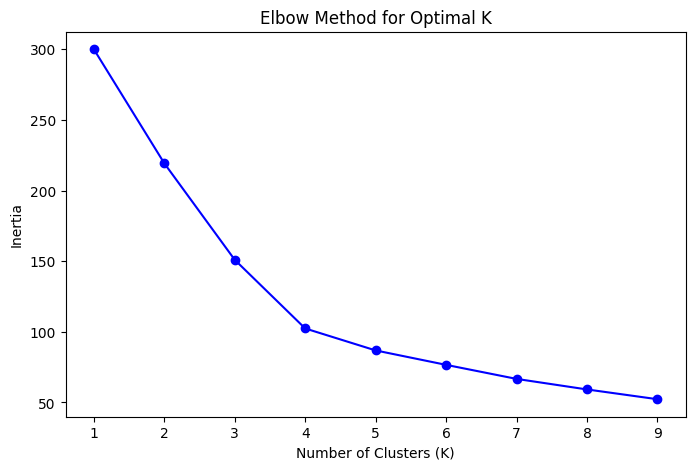

In [228]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import numpy as np

# Determine the optimal number of clusters using the Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(wd_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [229]:
# Apply PCA with all components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(wd_scaled)

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Print results
for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance), 1):
    print(f"PC{i}: {var:.4f} (Cumulative: {cum_var:.4f})")

PC1: 0.3488 (Cumulative: 0.3488)
PC2: 0.3333 (Cumulative: 0.6822)
PC3: 0.3178 (Cumulative: 1.0000)


In [230]:
# Choose the optimal number of clusters (based on the Elbow method)
optimal_k = 4

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
weekly_data["Cluster"] = kmeans.fit_predict(wd_scaled)

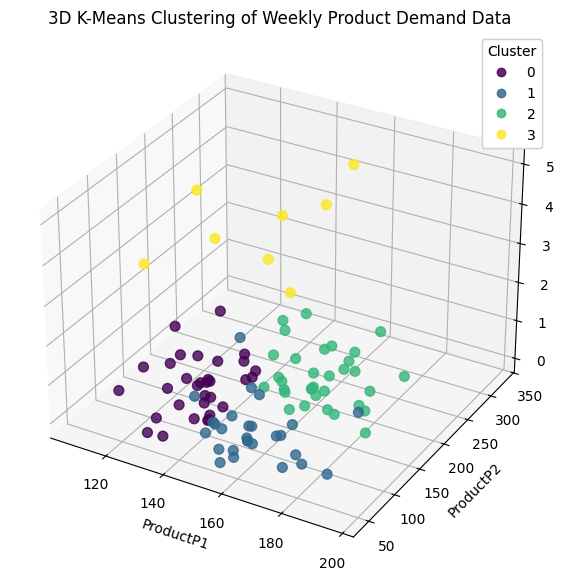

In [233]:
# Apply PCA with n_components=3
pca = PCA(n_components=3)
X_pca = pca.fit_transform(wd_scaled)

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with cluster colors
scatter = ax.scatter(weekly_data["ProductP1"], weekly_data["ProductP2"], weekly_data["ProductP5"], 
                      c=weekly_data["Cluster"], cmap="viridis", s=50, alpha=0.8)

# Labels and title
ax.set_xlabel("ProductP1")
ax.set_ylabel("ProductP2")
ax.set_zlabel("ProductP5")
ax.set_title("3D K-Means Clustering of Weekly Product Demand Data")

# Add a legend
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

# Show the plot
plt.show()

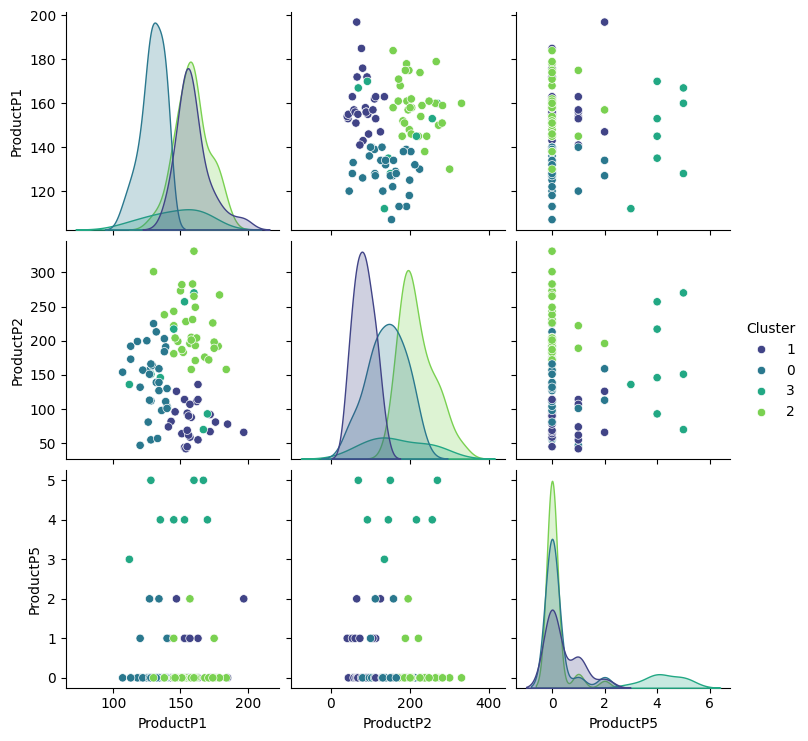

In [224]:
# Pair plot
weekly_data["Cluster"] = weekly_data["Cluster"].astype(str)
sns.pairplot(weekly_data, hue="Cluster", palette="viridis", diag_kind="kde")

In [186]:
# Rename columns for FBProphet
daily_data = df[["t"] + daily_products + ["price", "temperature"]]

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
daily_data["t"] = pd.date_range(start="2023-01-01", periods=len(daily_data), freq="D")

# Keep only necessary columns
daily_data = daily_data[["t", "ProductP3", "ProductP4", "price", "temperature"]]

C:\Users\Administrator\AppData\Local\Temp\ipykernel_1300\1450102266.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_data["t"] = pd.date_range(start="2023-01-01", periods=len(daily_data), freq="D")


In [187]:
daily_data.head()

,t,ProductP3,ProductP4,price,temperature
0,2023-01-01,266,113,1,18
1,2023-01-02,264,74,2,21
2,2023-01-03,317,116,1,19
3,2023-01-04,390,70,2,17
4,2023-01-05,440,141,1,18


In [156]:
daily_data.describe().T

,count,mean,min,25%,50%,75%,max,std
t,100,2023-02-19 12:00:00,2023-01-01 00:00:00,2023-01-25 18:00:00,2023-02-19 12:00:00,2023-03-16 06:00:00,2023-04-10 00:00:00,NaN
ProductP3,100.0,631.58,203.0,491.75,611.0,770.5,1141.0,202.8871
ProductP4,100.0,80.12,11.0,55.75,70.0,100.25,194.0,36.780891
price,100.0,1.47,1.0,1.0,1.0,2.0,2.0,0.501614
temperature,100.0,13.02,2.0,9.0,13.0,17.0,26.0,5.915192


In [207]:
# Standardize the data
dd_scaled = scaler.fit_transform(daily_data[["ProductP3", "ProductP4", "price", "temperature"]])

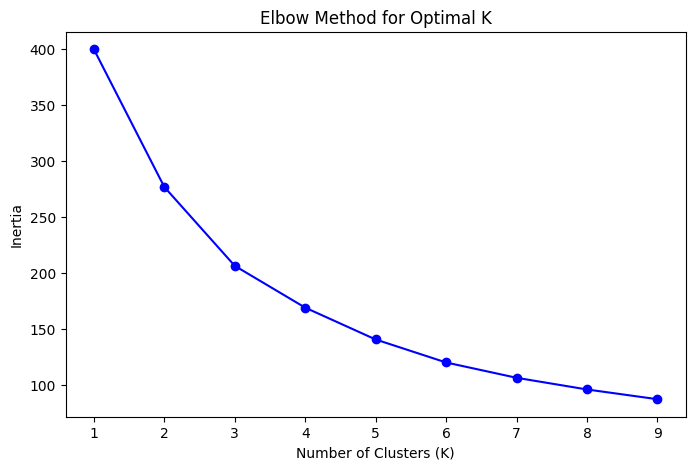

In [208]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import numpy as np

# Determine the optimal number of clusters using the Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(dd_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [209]:
# Apply PCA with all components
pca = PCA(n_components=4)
X_pca = pca.fit_transform(dd_scaled)

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Print results
for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance), 1):
    print(f"PC{i}: {var:.4f} (Cumulative: {cum_var:.4f})")

PC1: 0.4500 (Cumulative: 0.4500)
PC2: 0.2942 (Cumulative: 0.7442)
PC3: 0.2009 (Cumulative: 0.9451)
PC4: 0.0549 (Cumulative: 1.0000)


In [216]:
# Choose the optimal number of clusters (based on the Elbow method)
optimal_k = 4

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
daily_data["Cluster"] = kmeans.fit_predict(wd_scaled)

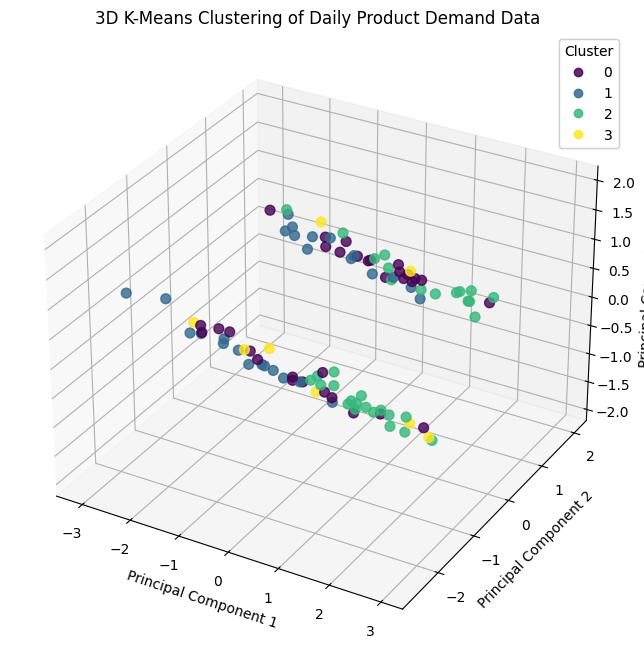

In [217]:
# Apply PCA with n_components=3
pca = PCA(n_components=3)
X_pca = pca.fit_transform(dd_scaled)

# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with cluster colors
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
                      c=daily_data["Cluster"], cmap="viridis", s=50, alpha=0.8)

# Labels and title
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D K-Means Clustering of Daily Product Demand Data")

# Add a legend
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

# Show the plot
plt.show()

In [159]:
# Choose the optimal number of clusters (based on the Elbow method)
optimal_k = 3

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
daily_data["Cluster"] = kmeans.fit_predict(dd_scaled)

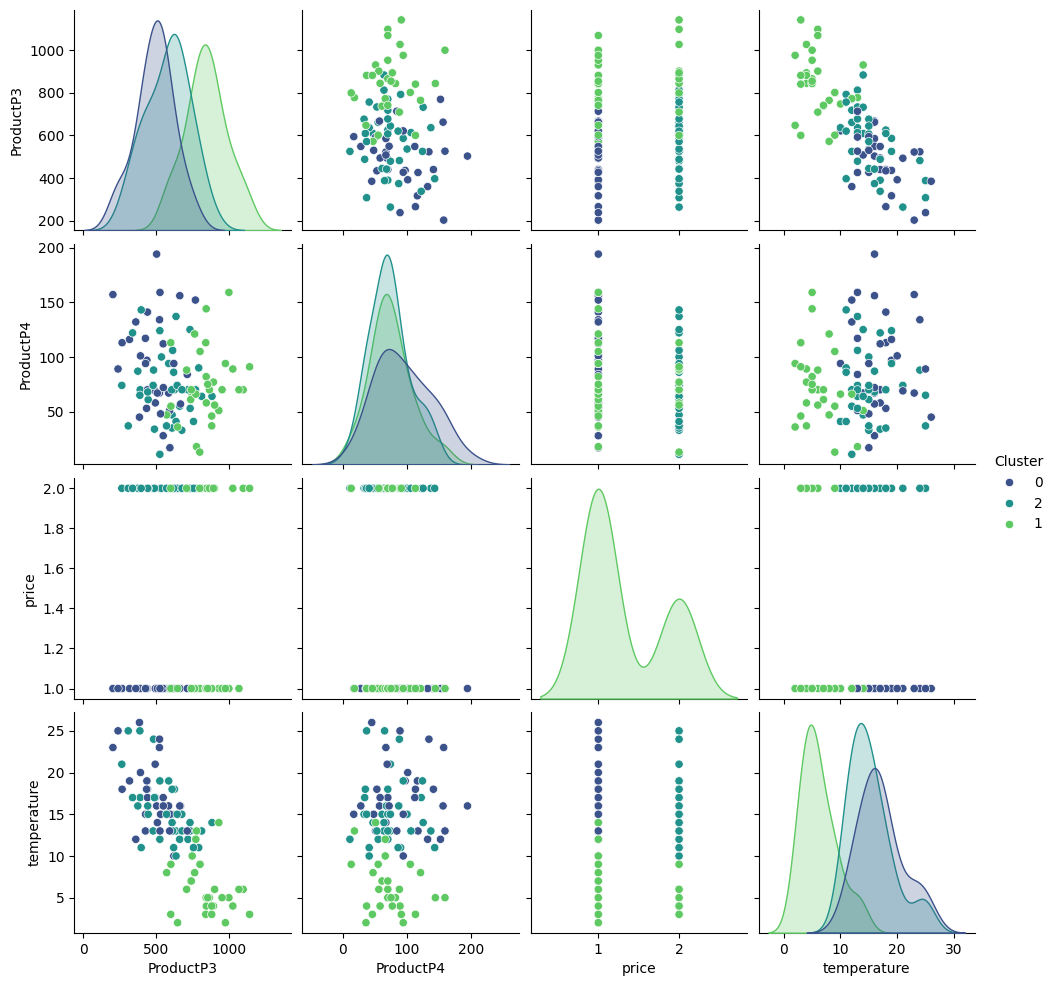

In [160]:
# Pair plot
daily_data["Cluster"] = daily_data["Cluster"].astype(str)
sns.pairplot(daily_data, hue="Cluster", palette="viridis", diag_kind="kde")

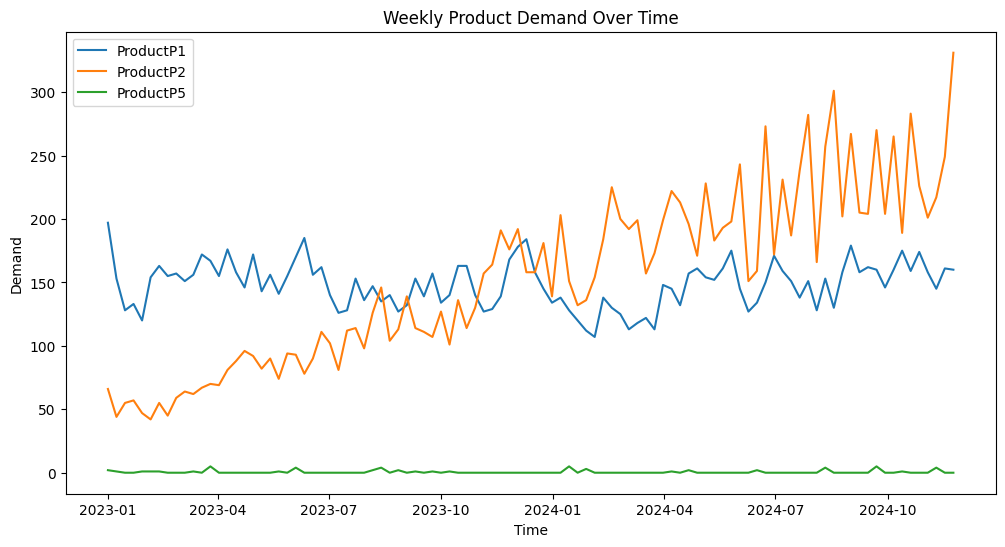

In [165]:
plt.figure(figsize=(12, 6))
plt.plot(weekly_data["t"], weekly_data["ProductP1"], label="ProductP1")
plt.plot(weekly_data["t"], weekly_data["ProductP2"], label="ProductP2")
plt.plot(weekly_data["t"], weekly_data["ProductP5"], label="ProductP5")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.title("Weekly Product Demand Over Time")
plt.show()

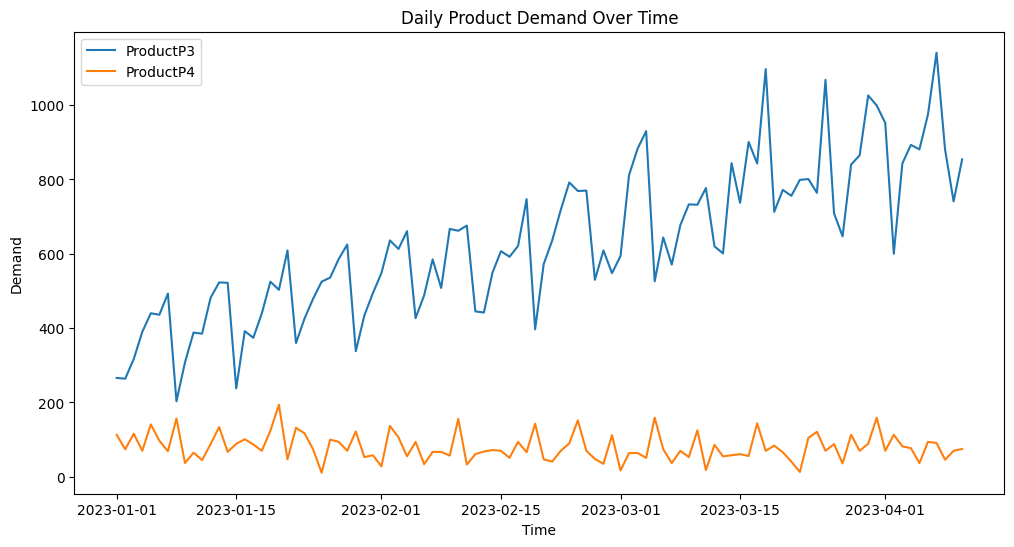

In [166]:
plt.figure(figsize=(12, 6))
plt.plot(daily_data["t"], daily_data["ProductP3"], label="ProductP3")
plt.plot(daily_data["t"], daily_data["ProductP4"], label="ProductP4")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.title("Daily Product Demand Over Time")
plt.show()

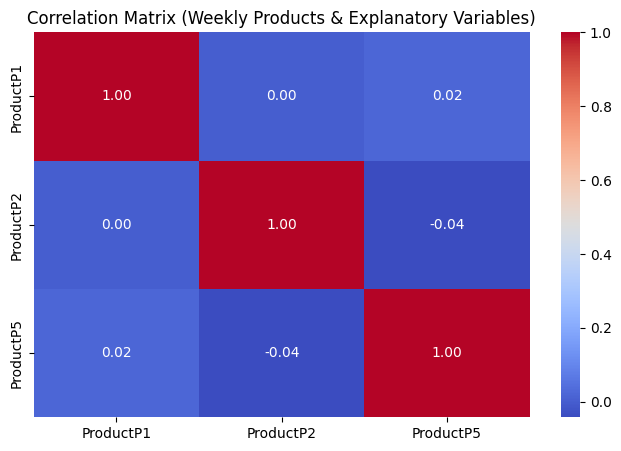

In [169]:
import seaborn as sns

# Compute correlation matrix for daily products and explanatory variables
corr_matrix = weekly_data[["ProductP1", "ProductP2", "ProductP5"]].corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Weekly Products & Explanatory Variables)")
plt.show()

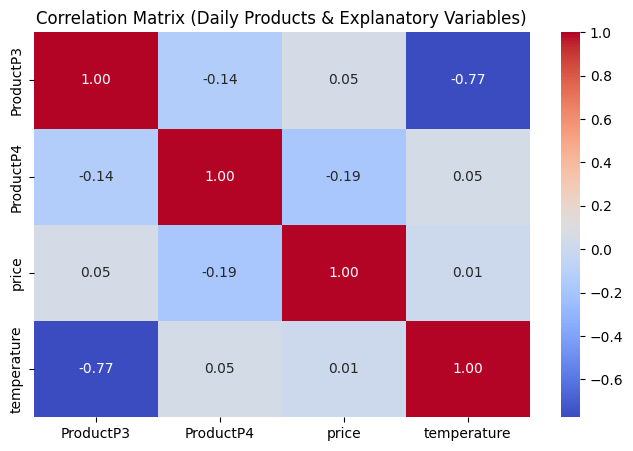

In [170]:
import seaborn as sns

# Compute correlation matrix for daily products and explanatory variables
corr_matrix = daily_data[["ProductP3", "ProductP4", "price", "temperature"]].corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Daily Products & Explanatory Variables)")
plt.show()

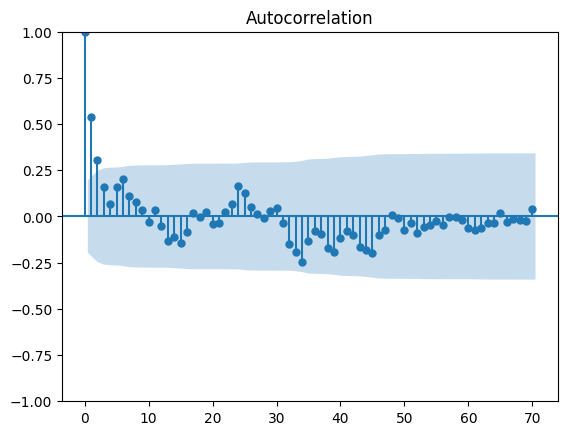

In [50]:
#Autocorelation weekly
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(weekly_data["ProductP1"], lags=70)  # Adjust lags based on your data length
plt.show()

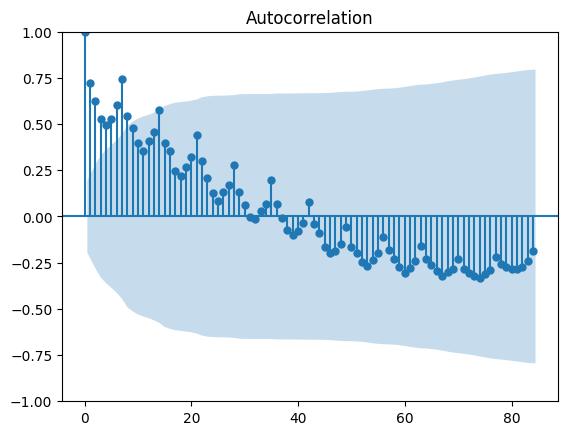

In [48]:
#Autocorelation daily
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(daily_data["ProductP3"], lags=84)  # Adjust lags based on your data length
plt.show()

In [75]:
from statsmodels.tsa.stattools import adfuller

# Function to check stationarity
def check_stationarity(series):
    result = adfuller(series)
    return {"Test Statistic": result[0], "p-value": result[1], "Stationary": result[1] < 0.05}

# Apply ADF test to all columns
stationarity_results = {col: check_stationarity(df[col]) for col in df.columns}
pd.DataFrame(stationarity_results).T

,Test Statistic,p-value,Stationary
t,2.348113,0.998984,False
ProductP1,-5.675633,0.000001,True
ProductP2,-0.861551,0.800371,False
ProductP3,-0.234873,0.934235,False
ProductP4,-11.455483,0.0,True
ProductP5,-11.152511,0.0,True
price,-2.616794,0.089576,False
temperature,-1.547096,0.510098,False


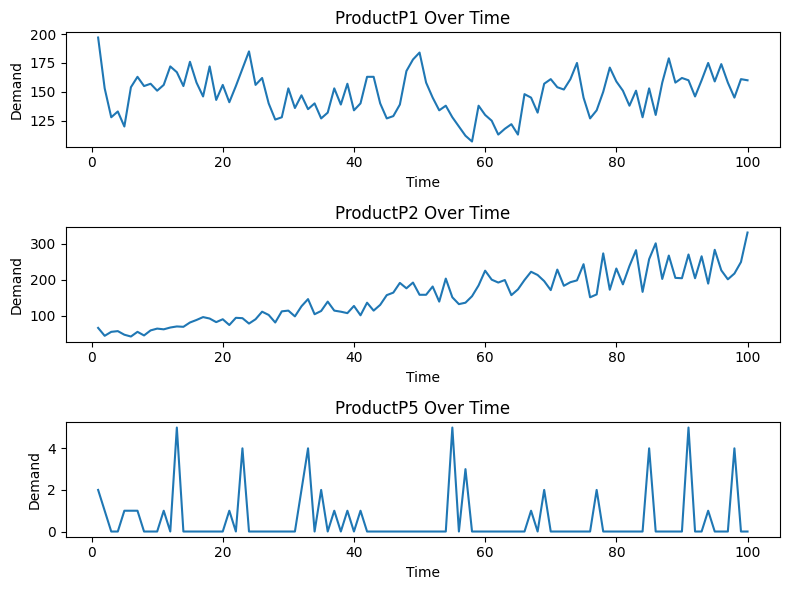

In [73]:
plt.figure(figsize=(8, 6))
cols = ["ProductP1","ProductP2","ProductP5"]

for idx, i in enumerate(cols):
    plt.subplot(3, 1, idx+1)
    plt.plot(weekly_data["t"], df[i], label=i)
    plt.xlabel("Time")
    plt.ylabel("Demand")
    plt.title(f"{i} Over Time")
plt.tight_layout()
plt.show()

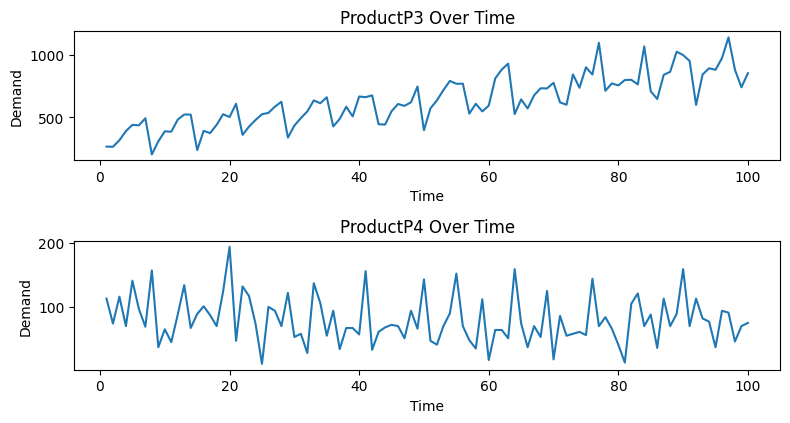

In [74]:
plt.figure(figsize=(8, 6))
cols = ["ProductP3","ProductP4"]

for idx, i in enumerate(cols):
    plt.subplot(3, 1, idx+1)
    plt.plot(daily_data["t"], df[i], label=i)
    plt.xlabel("Time")
    plt.ylabel("Demand")
    plt.title(f"{i} Over Time")
plt.tight_layout()
plt.show()

In [88]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition for ProductP1 (weekly) and ProductP4 (daily with explanatory variables)
weekly_series = df.loc[:weekly_end_dates["ProductP2"], "ProductP2"]
daily_series = df.loc[:daily_end_dates["ProductP3"], "ProductP3"]

# Decompose weekly product
weekly_decomp = seasonal_decompose(weekly_series, period=4, model="multiplicative")
daily_decomp = seasonal_decompose(daily_series, period=7, model="multiplicative")

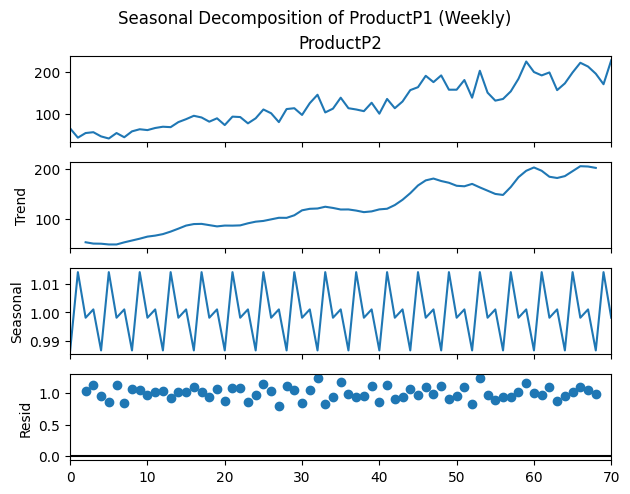

In [89]:
# Plot decompositions
weekly_decomp.plot()
plt.suptitle("Seasonal Decomposition of ProductP1 (Weekly)", y=1.02)
plt.show()

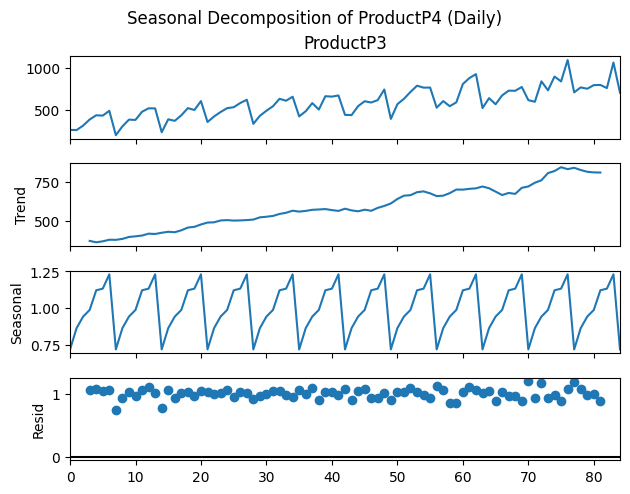

In [84]:
daily_decomp.plot()
plt.suptitle("Seasonal Decomposition of ProductP4 (Daily)", y=1.02)
plt.show()

In [349]:
from statsmodels.tsa.stattools import grangercausalitytests

# Run the Granger causality test
max_lag = 5  # Adjust as needed
gc_test = grangercausalitytests(df[['ProductP3', 'temperature']], maxlag=max_lag, verbose=False)

# Extract p-values for each lag
p_values = {lag: round(gc_test[lag][0]['ssr_chi2test'][1], 4) for lag in range(1, max_lag + 1)}

# Display p-values
print("Granger Causality p-values:", p_values)

Granger Causality p-values: {1: 0.0, 2: 0.0, 3: 0.0001, 4: 0.001, 5: 0.0128}


C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [353]:
from statsmodels.tsa.stattools import coint

# Compute correlation between ProductP3 and ProductP4
correlation_p3_p4 = df["ProductP3"].corr(df["ProductP4"])
print(f"Correlation between P3 and P4: {correlation_p3_p4:.2f}")

# Perform Engle-Granger cointegration test
coint_test_stat, p_value, _ = coint(df["ProductP3"], df["ProductP4"])
print(f"Cointegration test p-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("P3 and P4 are likely cointegrated (suggests using VECM).")
else:
    print("No strong cointegration detected (VAR might be a better choice).")

Correlation between P3 and P4: -0.14
Cointegration test p-value: 0.9594
No strong cointegration detected (VAR might be a better choice).


In [356]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Select only the relevant columns
data = df[["ProductP3", "ProductP4"]]

# Perform Johansen test
johansen_test = coint_johansen(data, det_order=0, k_ar_diff=1)

# Trace statistic and critical values
trace_stat = johansen_test.lr1
critical_values = johansen_test.cvt

# Display results
for i in range(len(trace_stat)):
    print(f"Rank {i}: Trace Statistic = {trace_stat[i]:.4f}, Critical Values = {critical_values[i]}")
    
    if trace_stat[i] > critical_values[i][1]:  # Compare with 5% critical value
        print("=> Evidence of cointegration at 5% significance level.")
    else:
        print("=> No strong evidence of cointegration.")

Rank 0: Trace Statistic = 66.5734, Critical Values = [13.4294 15.4943 19.9349]
=> Evidence of cointegration at 5% significance level.
Rank 1: Trace Statistic = 9.7024, Critical Values = [2.7055 3.8415 6.6349]
=> Evidence of cointegration at 5% significance level.


In [357]:
from statsmodels.tsa.stattools import coint

# Compute correlation between ProductP3 and ProductP4
correlation_p3_p4 = df["ProductP2"].corr(df["ProductP3"])
print(f"Correlation between P3 and P4: {correlation_p3_p4:.2f}")

# Perform Engle-Granger cointegration test
coint_test_stat, p_value, _ = coint(df["ProductP2"], df["ProductP3"])
print(f"Cointegration test p-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("P2 and P3 are likely cointegrated (suggests using VECM).")
else:
    print("No strong cointegration detected (VAR might be a better choice).")

Correlation between P3 and P4: 0.72
Cointegration test p-value: 0.6013
No strong cointegration detected (VAR might be a better choice).


In [120]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Load your sales demand data (ensure it's time-series indexed)
product1_sales = df['ProductP3']
product2_sales = df['ProductP4']

# Step 1: Check if both series are non-stationary
print("ADF Test for Product 1 Sales:", adfuller(product1_sales)[1])  # p-value
print("ADF Test for Product 2 Sales:", adfuller(product2_sales)[1])  # p-value

# Step 2: Run OLS regression
regression = sm.OLS(product1_sales, sm.add_constant(product2_sales)).fit()

# Step 3: Extract residuals
residuals = regression.resid

# Step 4: Test residuals for stationarity
adf_result = adfuller(residuals)
print("ADF Test for Residuals:", adf_result[1])  # p-value

if adf_result[1] < 0.05:
    print("The two product sales demands are cointegrated.")
else:
    print("No cointegration detected.")

ADF Test for Product 1 Sales: 0.9342351563563018
ADF Test for Product 2 Sales: 5.72054444868074e-21
ADF Test for Residuals: 0.9315229593091823
No cointegration detected.


### Model Development

### Product 1

In [113]:
# Rename columns for FBProphet
df_prophet = df.rename(columns={"t": "ds", "ProductP1": "y"})

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
df_prophet["ds"] = pd.date_range(start="2023-01-01", periods=len(df_prophet), freq="W")

# Keep only necessary columns
df_prophet = df_prophet[["ds", "y"]]

In [114]:
df_prophet.head()

,ds,y
0,2023-01-01,197
1,2023-01-08,153
2,2023-01-15,128
3,2023-01-22,133
4,2023-01-29,120


In [115]:
from prophet import Prophet

# Initialize Prophet model
model = Prophet()
# model.add_regressor("temp")  # Add temperature as an external regressor

# Fit the model
model.fit(df_prophet)

# Create future dataframe (next 30 weeks)
future = model.make_future_dataframe(periods=30)
# future["temp"] = df_prophet["temp"].mean()  # Assuming average temperature for future predictions

# Forecast
forecast = model.predict(future)

03:45:34 - cmdstanpy - INFO - Chain [1] start processing
03:45:34 - cmdstanpy - INFO - Chain [1] done processing


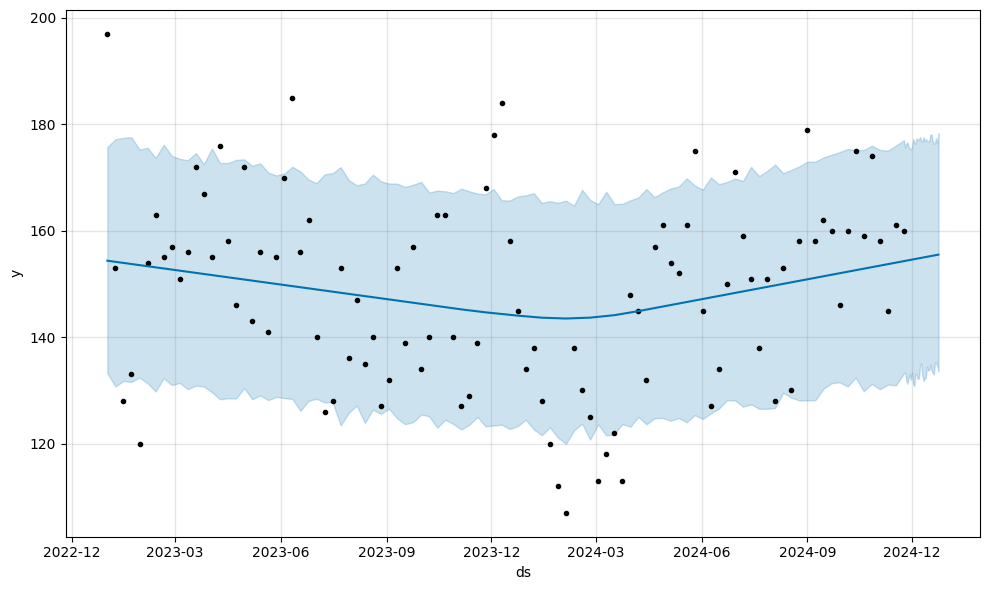

In [116]:
import matplotlib.pyplot as plt

# Plot forecast
fig = model.plot(forecast)
plt.show()

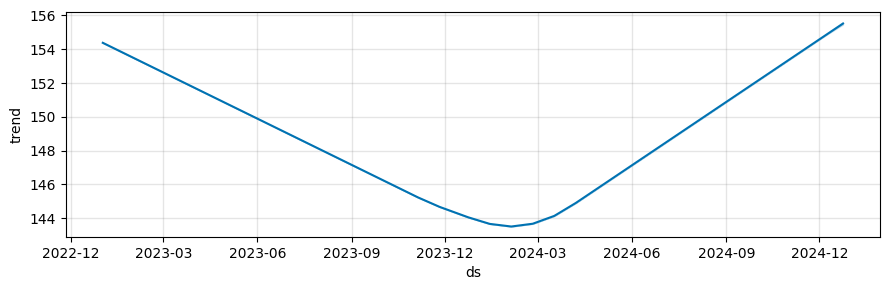

In [117]:
# Plot forecast components (trend, seasonality, effect of temp)
fig2 = model.plot_components(forecast)
plt.show()

### Hyper Parameter tuning product 01

In [118]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
import numpy as np

# Define hyperparameter grid
param_grid = {
    "changepoint_prior_scale": [0.001, 0.01, 0.05, 0.1, 0.5],
    "seasonality_prior_scale": [0.1, 1.0, 10.0, 20.0],
    "seasonality_mode": ["additive", "multiplicative"]
}

# Create all combinations of parameters
grid = list(ParameterGrid(param_grid))

# Split dataset for cross-validation
split_point = int(len(df_prophet) * 0.8)  # 80% train, 20% test
train_df = df_prophet[:split_point]
test_df = df_prophet[split_point:]

best_model = None
best_mse = float("inf")
best_params = None

for params in grid:
    # Initialize and fit model
    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    # model.add_regressor("temp")
    model.fit(train_df)
    
    # Make future dataframe
    future = model.make_future_dataframe(periods=len(test_df))
    # future["temp"] = test_df["temp"].values  # Use actual future temperature values

    # Predict
    forecast = model.predict(future)
    
    # Calculate error (Mean Squared Error)
    mse = np.mean((forecast["yhat"].iloc[-len(test_df):].values - test_df["y"].values) ** 2)
    
    # Save the best model
    if mse < best_mse:
        best_mse = mse
        best_model = model
        best_params = params

print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

03:45:36 - cmdstanpy - INFO - Chain [1] start processing
03:45:36 - cmdstanpy - INFO - Chain [1] done processing
03:45:37 - cmdstanpy - INFO - Chain [1] start processing
03:45:37 - cmdstanpy - INFO - Chain [1] done processing
03:45:37 - cmdstanpy - INFO - Chain [1] start processing
03:45:37 - cmdstanpy - INFO - Chain [1] done processing
03:45:37 - cmdstanpy - INFO - Chain [1] start processing
03:45:37 - cmdstanpy - INFO - Chain [1] done processing
03:45:38 - cmdstanpy - INFO - Chain [1] start processing
03:45:38 - cmdstanpy - INFO - Chain [1] done processing
03:45:38 - cmdstanpy - INFO - Chain [1] start processing
03:45:38 - cmdstanpy - INFO - Chain [1] done processing
03:45:38 - cmdstanpy - INFO - Chain [1] start processing
03:45:38 - cmdstanpy - INFO - Chain [1] done processing
03:45:38 - cmdstanpy - INFO - Chain [1] start processing
03:45:39 - cmdstanpy - INFO - Chain [1] done processing
03:45:39 - cmdstanpy - INFO - Chain [1] start processing
03:45:39 - cmdstanpy - INFO - Chain [1]

Best Parameters: {'changepoint_prior_scale': 0.5, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 0.1}
Best MSE: 202.5794549236196


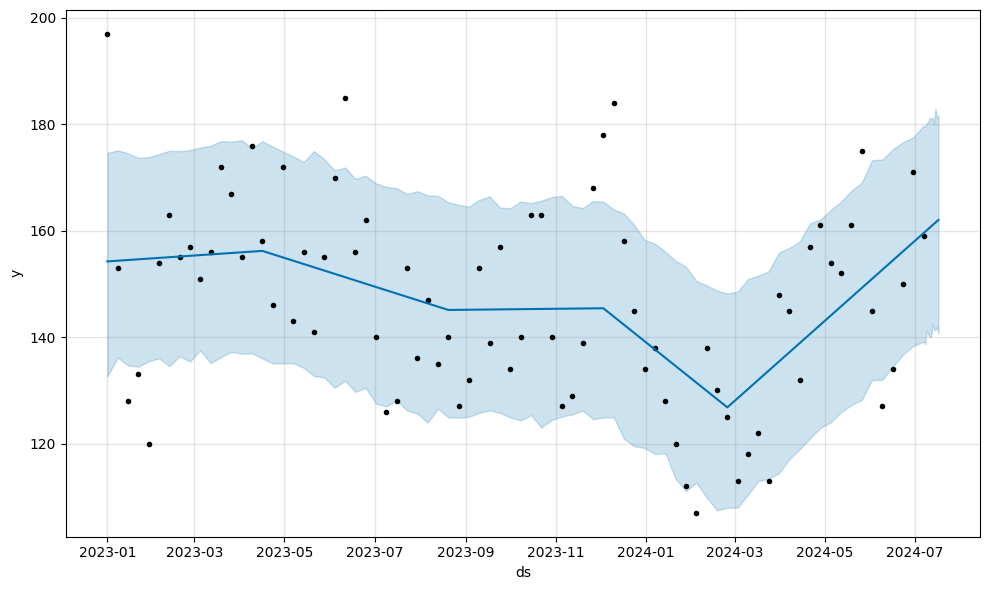

In [119]:
import matplotlib.pyplot as plt

# Predict using the best model
future = best_model.make_future_dataframe(periods=10)
# future["temp"] = df_prophet["temp"].mean()  # Assuming avg temperature

forecast = best_model.predict(future)

# Plot the forecast
best_model.plot(forecast)
plt.show()

In [122]:
from prophet.diagnostics import cross_validation, performance_metrics

# Adjust parameters for small dataset
df_cv = cross_validation(best_model, 
                         horizon="70 days",   
                         period="14 days",    
                         initial="480 days")  

# Evaluate performance
df_perf = performance_metrics(df_cv)
df_perf

  0%|          | 0/1 [00:00<?, ?it/s]

03:46:46 - cmdstanpy - INFO - Chain [1] start processing
03:46:47 - cmdstanpy - INFO - Chain [1] done processing


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,7 days,271.283195,16.470677,16.470677,0.106952,0.106952,0.112995,1.0
1,14 days,195.016200,13.964820,13.964820,0.091874,0.091874,0.096297,1.0
2,21 days,504.405036,22.458963,22.458963,0.139497,0.139497,0.149956,0.0
3,28 days,1292.625879,35.953107,35.953107,0.205446,0.205446,0.228966,0.0
4,35 days,29.672532,5.447250,5.447250,0.037567,0.037567,0.038286,1.0
5,42 days,170.527210,13.058607,13.058607,0.102824,0.102824,0.097796,1.0
6,49 days,43.092181,6.564463,6.564463,0.048989,0.048989,0.047817,1.0
7,56 days,79.739182,8.929680,8.929680,0.059531,0.059531,0.061358,1.0
8,63 days,865.761367,29.423823,29.423823,0.172069,0.172069,0.188267,0.0
9,70 days,286.217587,16.917966,16.917966,0.106402,0.106402,0.112381,1.0


### Product 2

In [171]:
# Rename columns for FBProphet
df_prophet = df.rename(columns={"t": "ds", "ProductP2": "y"})

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
df_prophet["ds"] = pd.date_range(start="2023-01-01", periods=len(df_prophet), freq="W")

# Keep only necessary columns
df_prophet = df_prophet[["ds", "y"]]

In [172]:
df_prophet.head()

,ds,y
0,2023-01-01,66
1,2023-01-08,44
2,2023-01-15,55
3,2023-01-22,57
4,2023-01-29,47


In [173]:
from prophet import Prophet

# Initialize Prophet model
model = Prophet()
# model.add_regressor("temp")  # Add temperature as an external regressor

# Fit the model
model.fit(df_prophet)

# Create future dataframe (next 30 weeks)
future = model.make_future_dataframe(periods=30)
# future["temp"] = df_prophet["temp"].mean()  # Assuming average temperature for future predictions

# Forecast
forecast = model.predict(future)

04:17:38 - cmdstanpy - INFO - Chain [1] start processing
04:17:38 - cmdstanpy - INFO - Chain [1] done processing


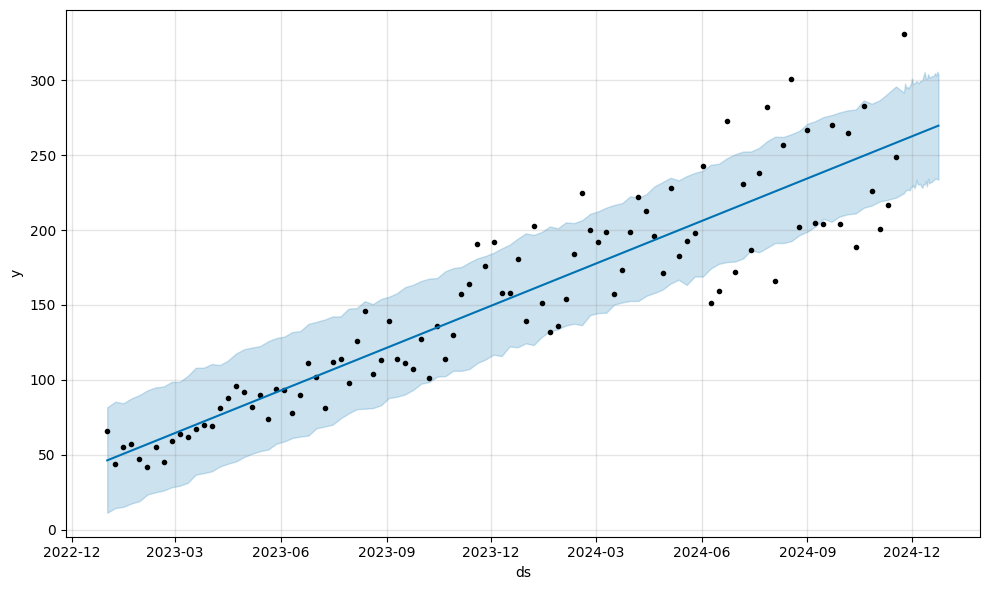

In [174]:
import matplotlib.pyplot as plt

# Plot forecast
fig = model.plot(forecast)
plt.show()

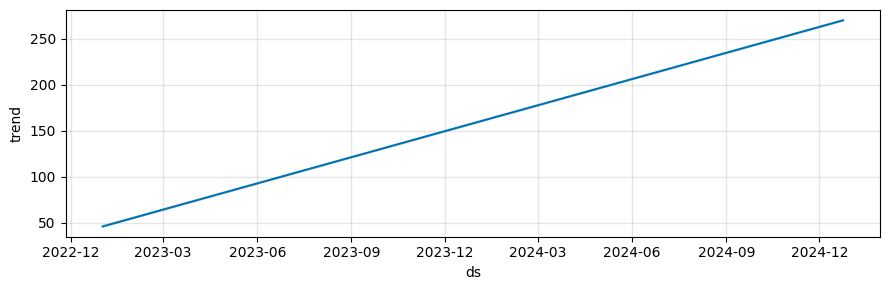

In [175]:
# Plot forecast components (trend, seasonality, effect of temp)
fig2 = model.plot_components(forecast)
plt.show()

### Hyper Parameter tuning product 02

In [176]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
import numpy as np

# Define hyperparameter grid
param_grid = {
    "changepoint_prior_scale": [0.001, 0.01, 0.02, 0.03, 0.05],
    "seasonality_prior_scale": [0.05,0.06,0.08,0.1, 0.15, 0.2],
    "seasonality_mode": ["additive", "multiplicative"]
}

# Create all combinations of parameters
grid = list(ParameterGrid(param_grid))

# Split dataset for cross-validation
split_point = int(len(df_prophet) * 0.8)  # 80% train, 20% test
train_df = df_prophet[:split_point]
test_df = df_prophet[split_point:]

best_model = None
best_mse = float("inf")
best_params = None

for params in grid:
    # Initialize and fit model
    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    # model.add_regressor("temp")
    model.fit(train_df)
    
    # Make future dataframe
    future = model.make_future_dataframe(periods=len(test_df))
    # future["temp"] = test_df["temp"].mean()  # Use actual future temperature values

    # Predict
    forecast = model.predict(future)
    
    # Calculate error (Mean Squared Error)
    mse = np.mean((forecast["yhat"].iloc[-len(test_df):].values - test_df["y"].values) ** 2)
    
    # Save the best model
    if mse < best_mse:
        best_mse = mse
        best_model = model
        best_params = params

print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

04:18:02 - cmdstanpy - INFO - Chain [1] start processing
04:18:02 - cmdstanpy - INFO - Chain [1] done processing
04:18:03 - cmdstanpy - INFO - Chain [1] start processing
04:18:03 - cmdstanpy - INFO - Chain [1] done processing
04:18:03 - cmdstanpy - INFO - Chain [1] start processing
04:18:04 - cmdstanpy - INFO - Chain [1] done processing
04:18:04 - cmdstanpy - INFO - Chain [1] start processing
04:18:05 - cmdstanpy - INFO - Chain [1] done processing
04:18:05 - cmdstanpy - INFO - Chain [1] start processing
04:18:05 - cmdstanpy - INFO - Chain [1] done processing
04:18:06 - cmdstanpy - INFO - Chain [1] start processing
04:18:06 - cmdstanpy - INFO - Chain [1] done processing
04:18:06 - cmdstanpy - INFO - Chain [1] start processing
04:18:07 - cmdstanpy - INFO - Chain [1] done processing
04:18:07 - cmdstanpy - INFO - Chain [1] start processing
04:18:08 - cmdstanpy - INFO - Chain [1] done processing
04:18:08 - cmdstanpy - INFO - Chain [1] start processing
04:18:09 - cmdstanpy - INFO - Chain [1]

Best Parameters: {'changepoint_prior_scale': 0.01, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 0.05}
Best MSE: 1987.1841257558183


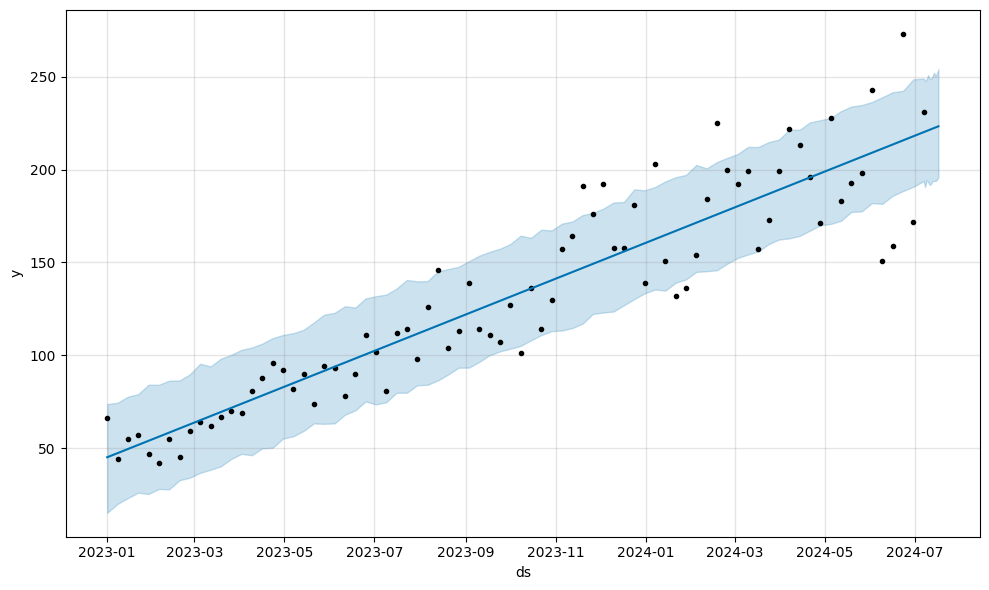

In [178]:
import matplotlib.pyplot as plt

# Predict using the best model
future = best_model.make_future_dataframe(periods=10)
# future["temp"] = df_prophet["temp"].mean()  # Assuming avg temperature

forecast = best_model.predict(future)

# Plot the forecast
best_model.plot(forecast)
plt.show()

In [179]:
from prophet.diagnostics import cross_validation, performance_metrics

# Adjust parameters for small dataset
df_cv = cross_validation(best_model, 
                         horizon="70 days",   
                         period="14 days",    
                         initial="480 days")  

# Evaluate performance
df_perf = performance_metrics(df_cv)
df_perf

  0%|          | 0/1 [00:00<?, ?it/s]

04:19:05 - cmdstanpy - INFO - Chain [1] start processing
04:19:05 - cmdstanpy - INFO - Chain [1] done processing


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,7 days,592.574197,24.342847,24.342847,0.106767,0.106767,0.112788,1.0
1,14 days,526.614240,22.948077,22.948077,0.125399,0.125399,0.118001,0.0
2,21 days,232.227153,15.239001,15.239001,0.078959,0.078959,0.075960,1.0
3,28 days,156.999022,12.529925,12.529925,0.063282,0.063282,0.061342,1.0
4,35 days,910.781153,30.179151,30.179151,0.124194,0.124194,0.132417,0.0
5,42 days,4110.319442,64.111773,64.111773,0.424581,0.424581,0.350231,0.0
6,49 days,3410.875021,58.402697,58.402697,0.367313,0.367313,0.310320,0.0
7,56 days,2841.570038,53.306379,53.306379,0.195261,0.195261,0.216388,0.0
8,63 days,2498.454742,49.984545,49.984545,0.290608,0.290608,0.253739,0.0
9,70 days,45.219317,6.724531,6.724531,0.029111,0.029111,0.029540,1.0


### Product 3

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import VECM, select_order
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import itertools

In [23]:
# Rename columns for FBProphet
df_vecm = df.rename(columns={"t": "date", "ProductP3": "ProductP3", "ProductP4": "ProductP4", "temperature": "temperature", "price": "price"})

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
df_vecm["date"] = pd.date_range(start="2023-01-01", periods=len(df_vecm), freq="D")

# Keep only necessary columns
df_vecm = df_vecm[["date", "ProductP3", "ProductP4", "temperature", "price"]]
df_vecm.set_index('date', inplace=True)

In [24]:
df_vecm.head()

,ProductP3,ProductP4,temperature,price
date,,,,
2023-01-01,266,113,18,1
2023-01-02,264,74,21,2
2023-01-03,317,116,19,1
2023-01-04,390,70,17,2
2023-01-05,440,141,18,1


In [50]:
# Perform Johansen cointegration test
result = coint_johansen(df_vecm[['ProductP3', 'ProductP4']], det_order=0, k_ar_diff=1)

# Print test results
print("Johansen Cointegration Test Results:")
print("Test Statistics:", result.lr1)
print("Critical Values (90%, 95%, 99%):", result.cvt)

# Interpret the results
print("\nInterpretation and Conclusion:")

# Compare test statistics to critical values
for i, test_stat in enumerate(result.lr1):
    cv_90, cv_95, cv_99 = result.cvt[i]
    print(f"\nFor hypothesis {i}:")
    print(f"Test Statistic: {test_stat}")
    print(f"Critical Values (90%, 95%, 99%): {cv_90}, {cv_95}, {cv_99}")

    if test_stat > cv_99:
        print(f"Conclusion: Reject the null hypothesis at the 99% confidence level.")
    elif test_stat > cv_95:
        print(f"Conclusion: Reject the null hypothesis at the 95% confidence level.")
    elif test_stat > cv_90:
        print(f"Conclusion: Reject the null hypothesis at the 90% confidence level.")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis.")

# Final conclusion
if result.lr1[0] > result.cvt[0, 2]:  # Compare first test stat to 99% critical value
    print("\nOverall Conclusion:")
    print("There is strong evidence of cointegration between the variables.")
    print("The number of cointegrating relationships is at least 1.")
    if result.lr1[1] > result.cvt[1, 2]:  # Compare second test stat to 99% critical value
        print("There is evidence of more than one cointegrating relationship.")
else:
    print("\nOverall Conclusion:")
    print("There is no strong evidence of cointegration between the variables.")

Johansen Cointegration Test Results:
Test Statistics: [66.57336318  9.7023805 ]
Critical Values (90%, 95%, 99%): [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Interpretation and Conclusion:

For hypothesis 0:
Test Statistic: 66.57336318210143
Critical Values (90%, 95%, 99%): 13.4294, 15.4943, 19.9349
Conclusion: Reject the null hypothesis at the 99% confidence level.

For hypothesis 1:
Test Statistic: 9.702380503870202
Critical Values (90%, 95%, 99%): 2.7055, 3.8415, 6.6349
Conclusion: Reject the null hypothesis at the 99% confidence level.

Overall Conclusion:
There is strong evidence of cointegration between the variables.
The number of cointegrating relationships is at least 1.
There is evidence of more than one cointegrating relationship.


In [26]:
from statsmodels.tsa.vector_ar.vecm import VECM

# Fit VECMX model
model = VECM(df_vecm[['ProductP3', 'ProductP4']], exog=df_vecm[['temperature', 'price']], coint_rank=1, k_ar_diff=1)
results = model.fit()

# model summary
print(results.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation ProductP3
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
exog1           -3.4165      2.077     -1.645      0.100      -7.488       0.654
exog2           29.4845     16.657      1.770      0.077      -3.163      62.132
L1.ProductP3    -0.2431      0.099     -2.457      0.014      -0.437      -0.049
L1.ProductP4     0.4814      0.341      1.412      0.158      -0.187       1.150
Det. terms outside the coint. relation & lagged endog. parameters for equation ProductP4
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
exog1            2.7138      0.582      4.666      0.000       1.574       3.854
exog2           -8.7118      4.665     -1.868      0.062     -17.854       0.431
L1.ProductP3

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [29]:
# Forecast
# For forecasting, you need to provide future values of exogenous variables
future_exog = np.tile(df_vecm[['temperature', 'price']].iloc[-1:].values, (10, 1))  # Repeat last row for 10 steps
forecast = results.predict(steps=10, exog_fc=future_exog)  # Use exog_future for exogenous variables
print(forecast)

[[840.91774729  83.4486396 ]
 [864.6005213   79.25138167]
 [870.33516885  82.44678645]
 [885.23719527  82.38887181]
 [895.70332764  83.99124131]
 [908.35869117  84.78535573]
 [919.93931494  85.97738484]
 [932.04814396  86.97393496]
 [943.89742152  88.06654303]
 [955.87424032  89.11194855]]


In [30]:
# Train-test split
train_size = int(0.8 * len(df_vecm))  # 80% training, 20% testing
train_data = df_vecm.iloc[:train_size]
test_data = df_vecm.iloc[train_size:]

# Fit VECM model on training data
model = VECM(
    endog=train_data[['ProductP3', 'ProductP4']],  # Endogenous variables
    exog=train_data[['temperature', 'price']],     # Exogenous variables
    coint_rank=1,                                  # Cointegration rank
    k_ar_diff=1                                    # Lag order
)
results = model.fit()

# Forecast on testing data
# Provide future values of exogenous variables for the testing period
future_exog = test_data[['temperature', 'price']].values
forecast = results.predict(steps=len(test_data), exog_fc=future_exog)

# Extract forecasted values for productp2
forecast_productp2 = forecast[:, 0]

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [31]:
# Evaluate performance
mae = mean_absolute_error(test_data['ProductP3'], forecast_productp2)
rmse = np.sqrt(mean_squared_error(test_data['ProductP3'], forecast_productp2))
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')

Mean Absolute Error (MAE): 244.36735798577644
Root Mean Squared Error (RMSE): 306.81189841975066


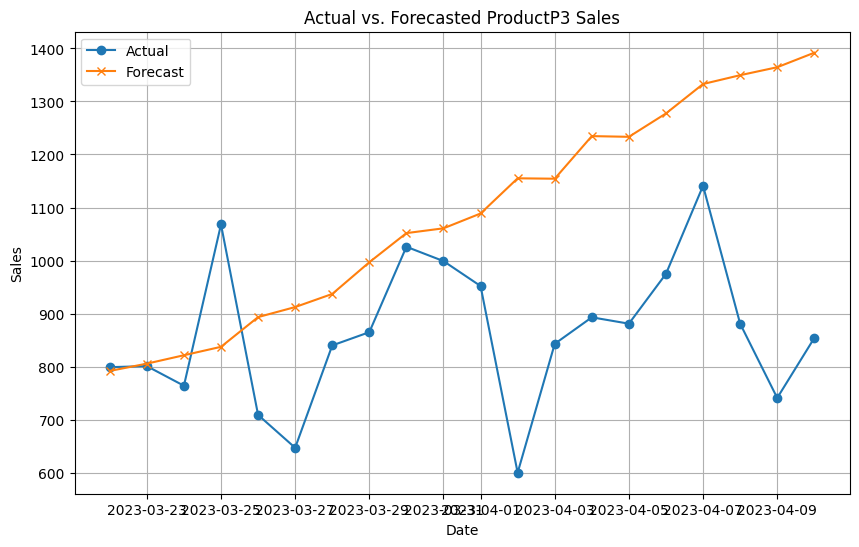

In [32]:
# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['ProductP3'], label='Actual', marker='o')
plt.plot(test_data.index, forecast_productp2, label='Forecast', marker='x')
plt.title('Actual vs. Forecasted ProductP3 Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

### Hyper Parameter tuning product 3

In [36]:
# Step 3: Perform Grid Search
best_aic = float('inf')
best_params = None

for params in itertools.product(*param_grid.values()):
    coint_rank, k_ar_diff, deterministic = params
    try:
        # Fit VECM model
        model = VECM(
            endog=df_vecm[['ProductP3', 'ProductP4']],  # Endogenous variables
            exog=df_vecm[['temperature', 'price']],     # Exogenous variables
            coint_rank=coint_rank,                   # Cointegration rank
            k_ar_diff=k_ar_diff,                     # Lag order
            deterministic=deterministic              # Deterministic terms
        )
        results = model.fit()

        # Compute AIC manually
        llf = results.llf  # Log-likelihood

        # Calculate the number of parameters
        n_vars = len(df_vecm.columns)  # Number of variables
        n_lags = k_ar_diff  # Number of lags
        n_coint = coint_rank  # Cointegration rank
        n_params = n_vars * n_lags + n_coint * n_vars  # Total number of parameters

        aic = -2 * llf + 2 * n_params

        print(f"Params: {params}, AIC: {aic}")

        # Update best parameters if current model is better
        if aic < best_aic:
            best_aic = aic
            best_params = params
    except Exception as e:
        print(f"Error with params {params}: {e}")

print(f"Best Parameters: {best_params}, Best AIC: {best_aic}")

Params: (1, 1, 'nc'), AIC: 2228.142209506669
Params: (1, 1, 'co'), AIC: 2202.4456284006833
Params: (1, 1, 'lo'), AIC: 2208.8523499943367
Params: (1, 2, 'nc'), AIC: 2204.9938438395047
Params: (1, 2, 'co'), AIC: 2163.4909062338493
Params: (1, 2, 'lo'), AIC: 2165.028253659109
Params: (1, 3, 'nc'), AIC: 2148.8870650873405
Params: (1, 3, 'co'), AIC: 2113.8898931414938
Params: (1, 3, 'lo'), AIC: 2124.026875675955
Params: (2, 1, 'nc'), AIC: 2226.231833945272
Params: (2, 1, 'co'), AIC: 2181.544927245414
Params: (2, 1, 'lo'), AIC: 2192.0926807232386
Params: (2, 2, 'nc'), AIC: 2204.233986070397
Params: (2, 2, 'co'), AIC: 2152.864602531027
Params: (2, 2, 'lo'), AIC: 2155.240502328448
Params: (2, 3, 'nc'), AIC: 2154.8142649080078
Params: (2, 3, 'co'), AIC: 2111.3514659633033
Params: (2, 3, 'lo'), AIC: 2123.1989931230937
Best Parameters: (2, 3, 'co'), Best AIC: 2111.3514659633033


C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No f

In [41]:
# Refit the model with the best hyperparameters
best_coint_rank, best_k_ar_diff, best_deterministic = best_params
best_model = VECM(
    endog=df_vecm[['ProductP3', 'ProductP4']],  # Endogenous variables
    exog=df_vecm[['temperature', 'price']],     # Exogenous variables
    coint_rank=best_coint_rank,              # Best cointegration rank
    k_ar_diff=best_k_ar_diff,                # Best lag order
    deterministic=best_deterministic         # Best deterministic terms
)
print (f"best_coint_rank: {best_coint_rank}")
print (f"best_k_ar_diff: {best_k_ar_diff}")
print (f"best_deterministic: {best_deterministic}")
best_results = best_model.fit()

best_coint_rank: 2
best_k_ar_diff: 3
best_deterministic: co


C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [42]:
# Display summary of the best model
print(best_results.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation ProductP3
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          696.6318    124.077      5.615      0.000     453.446     939.817
exog1          -14.6171      2.885     -5.066      0.000     -20.272      -8.962
exog2           20.8876     20.710      1.009      0.313     -19.704      61.479
L1.ProductP3    -0.1214      0.100     -1.219      0.223      -0.317       0.074
L1.ProductP4     2.1551      0.592      3.641      0.000       0.995       3.315
L2.ProductP3    -0.0351      0.093     -0.378      0.705      -0.217       0.147
L2.ProductP4     0.9447      0.485      1.949      0.051      -0.005       1.895
L3.ProductP3    -0.1175      0.087     -1.347      0.178      -0.289       0.054
L3.ProductP4    -0.3035      0.318     -0.954      0.340      -0.927       0.320
Det. terms outside t

In [43]:
# Forecast with the best model
future_exog = np.tile(df_vecm[['temperature', 'price']].iloc[-1:].values, (10, 1))  # Repeat last row for 10 steps
forecast = best_results.predict(steps=10, exog_fc=future_exog)
print(forecast)

[[919.03419779  34.93765468]
 [873.12891747  72.03487247]
 [894.65919584  98.52240729]
 [915.67610621  75.22170341]
 [841.05708249  69.92788202]
 [819.25204368  77.85377194]
 [851.92652036  72.5344735 ]
 [857.43783597  66.6481064 ]
 [848.94248314  78.03517542]
 [859.57594214  81.63333853]]


In [44]:
# Step 5: Validate the Model
train_data = df_vecm.iloc[:-10]  # Use all but the last 10 days for training
test_data = df_vecm.iloc[-10:]   # Last 10 days for testing

In [45]:
# Refit the model with the best hyperparameters
best_coint_rank, best_k_ar_diff, best_deterministic = best_params

# Fit the best model on the training data
best_model_train = VECM(endog=train_data[['ProductP3', 'ProductP4']],
                        exog=train_data[['temperature', 'price']],
                        coint_rank=best_coint_rank,
                        k_ar_diff=best_k_ar_diff,
                        deterministic=best_deterministic)
best_results_train = best_model_train.fit()

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [46]:
# Forecast on the test data
future_exog = np.tile(train_data[['temperature', 'price']].iloc[-1:].values, (10, 1))  # Repeat last row for 10 steps
forecast_test = best_results_train.predict(steps=10, exog_fc=future_exog)

In [47]:
# Calculate MAE
mae = mean_absolute_error(test_data['ProductP3'], forecast_test[:, 0])
print(f'Mean Absolute Error (MAE): {mae}')

Mean Absolute Error (MAE): 93.8282750830396


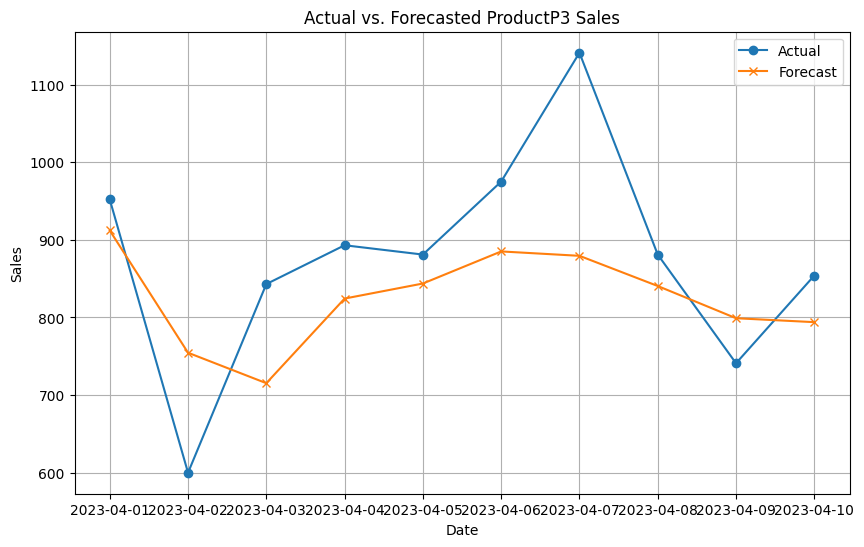

In [48]:
# Step 6: Visualize Results
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['ProductP3'], label='Actual', marker='o')
plt.plot(test_data.index, forecast_test[:, 0], label='Forecast', marker='x')
plt.title('Actual vs. Forecasted ProductP3 Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

### Product 4

In [51]:
# Rename columns for FBProphet
df_vecm = df.rename(columns={"t": "date", "ProductP3": "ProductP3", "ProductP4": "ProductP4", "temperature": "temperature", "price": "price"})

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
df_vecm["date"] = pd.date_range(start="2023-01-01", periods=len(df_vecm), freq="D")

# Keep only necessary columns
df_vecm = df_vecm[["date", "ProductP3", "ProductP4", "temperature", "price"]]
df_vecm.set_index('date', inplace=True)

In [52]:
df_vecm.head()

,ProductP3,ProductP4,temperature,price
date,,,,
2023-01-01,266,113,18,1
2023-01-02,264,74,21,2
2023-01-03,317,116,19,1
2023-01-04,390,70,17,2
2023-01-05,440,141,18,1


In [53]:
# Perform Johansen cointegration test
result = coint_johansen(df_vecm[['ProductP4', 'ProductP3']], det_order=0, k_ar_diff=1)

# Print test results
print("Johansen Cointegration Test Results:")
print("Test Statistics:", result.lr1)
print("Critical Values (90%, 95%, 99%):", result.cvt)

# Interpret the results
print("\nInterpretation and Conclusion:")

# Compare test statistics to critical values
for i, test_stat in enumerate(result.lr1):
    cv_90, cv_95, cv_99 = result.cvt[i]
    print(f"\nFor hypothesis {i}:")
    print(f"Test Statistic: {test_stat}")
    print(f"Critical Values (90%, 95%, 99%): {cv_90}, {cv_95}, {cv_99}")

    if test_stat > cv_99:
        print(f"Conclusion: Reject the null hypothesis at the 99% confidence level.")
    elif test_stat > cv_95:
        print(f"Conclusion: Reject the null hypothesis at the 95% confidence level.")
    elif test_stat > cv_90:
        print(f"Conclusion: Reject the null hypothesis at the 90% confidence level.")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis.")

# Final conclusion
if result.lr1[0] > result.cvt[0, 2]:  # Compare first test stat to 99% critical value
    print("\nOverall Conclusion:")
    print("There is strong evidence of cointegration between the variables.")
    print("The number of cointegrating relationships is at least 1.")
    if result.lr1[1] > result.cvt[1, 2]:  # Compare second test stat to 99% critical value
        print("There is evidence of more than one cointegrating relationship.")
else:
    print("\nOverall Conclusion:")
    print("There is no strong evidence of cointegration between the variables.")

Johansen Cointegration Test Results:
Test Statistics: [66.57336318  9.7023805 ]
Critical Values (90%, 95%, 99%): [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Interpretation and Conclusion:

For hypothesis 0:
Test Statistic: 66.5733631821014
Critical Values (90%, 95%, 99%): 13.4294, 15.4943, 19.9349
Conclusion: Reject the null hypothesis at the 99% confidence level.

For hypothesis 1:
Test Statistic: 9.702380503870202
Critical Values (90%, 95%, 99%): 2.7055, 3.8415, 6.6349
Conclusion: Reject the null hypothesis at the 99% confidence level.

Overall Conclusion:
There is strong evidence of cointegration between the variables.
The number of cointegrating relationships is at least 1.
There is evidence of more than one cointegrating relationship.


In [56]:
from statsmodels.tsa.vector_ar.vecm import VECM

# Fit VECMX model
model = VECM(df_vecm[['ProductP4', 'ProductP3']], exog=df_vecm[['temperature', 'price']], coint_rank=1, k_ar_diff=1)
results = model.fit()

# Display model summary
print(results.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation ProductP4
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
exog1            2.7138      0.582      4.666      0.000       1.574       3.854
exog2           -8.7118      4.665     -1.868      0.062     -17.854       0.431
L1.ProductP4    -0.0232      0.095     -0.243      0.808      -0.210       0.164
L1.ProductP3     0.0248      0.028      0.897      0.370      -0.029       0.079
Det. terms outside the coint. relation & lagged endog. parameters for equation ProductP3
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
exog1           -3.4165      2.077     -1.645      0.100      -7.488       0.654
exog2           29.4845     16.657      1.770      0.077      -3.163      62.132
L1.ProductP4

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [57]:
# Forecast
# For forecasting, you need to provide future values of exogenous variables
future_exog = np.tile(df_vecm[['temperature', 'price']].iloc[-1:].values, (10, 1))  # Repeat last row for 10 steps
forecast = results.predict(steps=10, exog_fc=future_exog)  # Use exog_future for exogenous variables
print(forecast)

[[ 83.4486396  840.91774729]
 [ 79.25138167 864.6005213 ]
 [ 82.44678645 870.33516885]
 [ 82.38887181 885.23719527]
 [ 83.99124131 895.70332764]
 [ 84.78535573 908.35869117]
 [ 85.97738484 919.93931494]
 [ 86.97393496 932.04814396]
 [ 88.06654303 943.89742152]
 [ 89.11194855 955.87424032]]


In [60]:
# Train-test split
train_size = int(0.8 * len(df_vecm))  # 80% training, 20% testing
train_data = df_vecm.iloc[:train_size]
test_data = df_vecm.iloc[train_size:]

# Fit VECM model on training data
model = VECM(
    endog=train_data[['ProductP4', 'ProductP3']],  # Endogenous variables
    exog=train_data[['temperature', 'price']],     # Exogenous variables
    coint_rank=1,                                  # Cointegration rank
    k_ar_diff=1                                    # Lag order
)
results = model.fit()

# Forecast on testing data
# Provide future values of exogenous variables for the testing period
future_exog = test_data[['temperature', 'price']].values
forecast = results.predict(steps=len(test_data), exog_fc=future_exog)

# Extract forecasted values for productp2
forecast_productp4 = forecast[:, 0]

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [61]:
# Evaluate performance
mae = mean_absolute_error(test_data['ProductP4'], forecast_productp4)
rmse = np.sqrt(mean_squared_error(test_data['ProductP4'], forecast_productp4))
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')

Mean Absolute Error (MAE): 28.784580676292677
Root Mean Squared Error (RMSE): 35.82689623166127


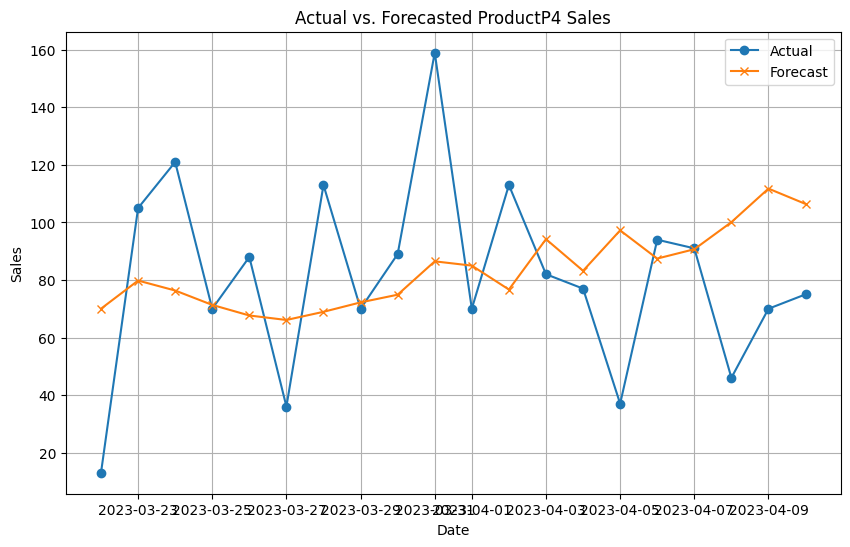

In [62]:
# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['ProductP4'], label='Actual', marker='o')
plt.plot(test_data.index, forecast_productp4, label='Forecast', marker='x')
plt.title('Actual vs. Forecasted ProductP4 Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

### Hyper Parameter tuning product 4

In [63]:
# Step 3: Perform Grid Search
best_aic = float('inf')
best_params = None

for params in itertools.product(*param_grid.values()):
    coint_rank, k_ar_diff, deterministic = params
    try:
        # Fit VECM model
        model = VECM(
            endog=df_vecm[['ProductP4', 'ProductP3']],  # Endogenous variables
            exog=df_vecm[['temperature', 'price']],     # Exogenous variables
            coint_rank=coint_rank,                   # Cointegration rank
            k_ar_diff=k_ar_diff,                     # Lag order
            deterministic=deterministic              # Deterministic terms
        )
        results = model.fit()

        # Compute AIC manually
        llf = results.llf  # Log-likelihood

        # Calculate the number of parameters
        n_vars = len(df_vecm.columns)  # Number of variables
        n_lags = k_ar_diff  # Number of lags
        n_coint = coint_rank  # Cointegration rank
        n_params = n_vars * n_lags + n_coint * n_vars  # Total number of parameters

        aic = -2 * llf + 2 * n_params

        print(f"Params: {params}, AIC: {aic}")

        # Update best parameters if current model is better
        if aic < best_aic:
            best_aic = aic
            best_params = params
    except Exception as e:
        print(f"Error with params {params}: {e}")

print(f"Best Parameters: {best_params}, Best AIC: {best_aic}")

Params: (1, 1, 'nc'), AIC: 2228.1422095066687
Params: (1, 1, 'co'), AIC: 2202.4456284006833
Params: (1, 1, 'lo'), AIC: 2208.8523499943367
Params: (1, 2, 'nc'), AIC: 2204.993843839505
Params: (1, 2, 'co'), AIC: 2163.4909062338493
Params: (1, 2, 'lo'), AIC: 2165.028253659109
Params: (1, 3, 'nc'), AIC: 2148.8870650873405
Params: (1, 3, 'co'), AIC: 2113.8898931414933
Params: (1, 3, 'lo'), AIC: 2124.026875675955
Params: (2, 1, 'nc'), AIC: 2226.2318339452713
Params: (2, 1, 'co'), AIC: 2181.544927245415
Params: (2, 1, 'lo'), AIC: 2192.0926807232386
Params: (2, 2, 'nc'), AIC: 2204.233986070397
Params: (2, 2, 'co'), AIC: 2152.864602531027
Params: (2, 2, 'lo'), AIC: 2155.2405023284473
Params: (2, 3, 'nc'), AIC: 2154.8142649080078
Params: (2, 3, 'co'), AIC: 2111.351465963303
Params: (2, 3, 'lo'), AIC: 2123.1989931230937
Best Parameters: (2, 3, 'co'), Best AIC: 2111.351465963303


C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No f

In [64]:
# Refit the model with the best hyperparameters
best_coint_rank, best_k_ar_diff, best_deterministic = best_params
best_model = VECM(
    endog=df_vecm[['ProductP4', 'ProductP3']],  # Endogenous variables
    exog=df_vecm[['temperature', 'price']],     # Exogenous variables
    coint_rank=best_coint_rank,              # Best cointegration rank
    k_ar_diff=best_k_ar_diff,                # Best lag order
    deterministic=best_deterministic         # Best deterministic terms
)
print (f"best_coint_rank: {best_coint_rank}")
print (f"best_k_ar_diff: {best_k_ar_diff}")
print (f"best_deterministic: {best_deterministic}")
best_results = best_model.fit()

best_coint_rank: 2
best_k_ar_diff: 3
best_deterministic: co


C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [65]:
# Display summary of the best model
print(best_results.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation ProductP4
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          138.1674     38.403      3.598      0.000      62.900     213.435
exog1           -0.7690      0.893     -0.861      0.389      -2.519       0.981
exog2           -7.5614      6.410     -1.180      0.238     -20.125       5.002
L1.ProductP4     0.0349      0.183      0.190      0.849      -0.324       0.394
L1.ProductP3     0.1284      0.031      4.168      0.000       0.068       0.189
L2.ProductP4    -0.1158      0.150     -0.772      0.440      -0.410       0.178
L2.ProductP3     0.0664      0.029      2.310      0.021       0.010       0.123
L3.ProductP4     0.0852      0.098      0.865      0.387      -0.108       0.278
L3.ProductP3     0.1560      0.027      5.775      0.000       0.103       0.209
Det. terms outside t

In [66]:
# Forecast with the best model
future_exog = np.tile(df_vecm[['temperature', 'price']].iloc[-1:].values, (10, 1))  # Repeat last row for 10 steps
forecast = best_results.predict(steps=10, exog_fc=future_exog)
print(forecast)

[[ 34.93765468 919.03419779]
 [ 72.03487247 873.12891747]
 [ 98.52240729 894.65919584]
 [ 75.22170341 915.67610621]
 [ 69.92788202 841.05708249]
 [ 77.85377194 819.25204368]
 [ 72.5344735  851.92652036]
 [ 66.6481064  857.43783597]
 [ 78.03517542 848.94248314]
 [ 81.63333853 859.57594214]]


In [67]:
# Step 5: Validate the Model
train_data = df_vecm.iloc[:-10]  # Use all but the last 10 days for training
test_data = df_vecm.iloc[-10:]   # Last 10 days for testing

In [68]:
# Refit the model with the best hyperparameters
best_coint_rank, best_k_ar_diff, best_deterministic = best_params

# Fit the best model on the training data
best_model_train = VECM(endog=train_data[['ProductP4', 'ProductP3']],
                        exog=train_data[['temperature', 'price']],
                        coint_rank=best_coint_rank,
                        k_ar_diff=best_k_ar_diff,
                        deterministic=best_deterministic)
best_results_train = best_model_train.fit()

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [69]:
# Forecast on the test data
future_exog = np.tile(train_data[['temperature', 'price']].iloc[-1:].values, (10, 1))  # Repeat last row for 10 steps
forecast_test = best_results_train.predict(steps=10, exog_fc=future_exog)

In [70]:
# Calculate MAE
mae = mean_absolute_error(test_data['ProductP4'], forecast_test[:, 0])
print(f'Mean Absolute Error (MAE): {mae}')

Mean Absolute Error (MAE): 18.174536637608348


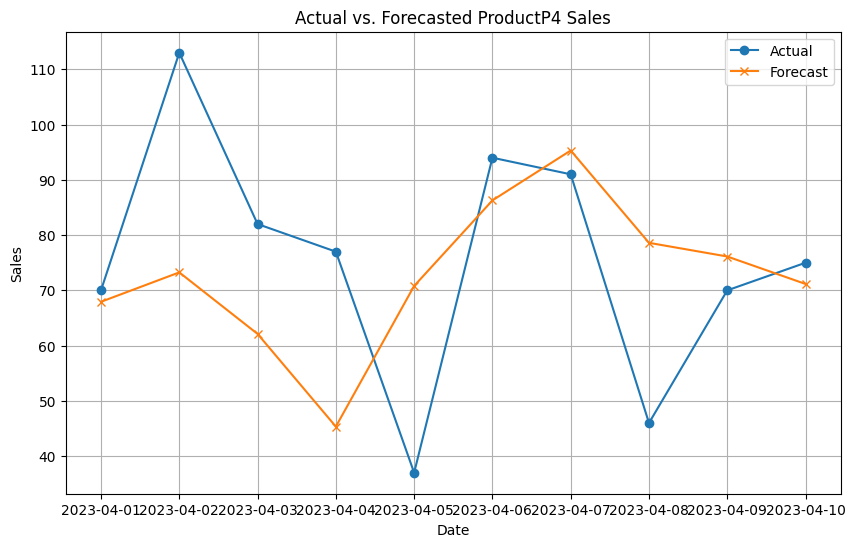

In [71]:
# Step 6: Visualize Results
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['ProductP4'], label='Actual', marker='o')
plt.plot(test_data.index, forecast_test[:, 0], label='Forecast', marker='x')
plt.title('Actual vs. Forecasted ProductP4 Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

### Product 5

In [101]:
# Rename columns for FBProphet
df_prophet = df.rename(columns={"t": "ds", "ProductP5": "y"})

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
df_prophet["ds"] = pd.date_range(start="2023-01-01", periods=len(df_prophet), freq="W")

# Keep only necessary columns
df_prophet = df_prophet[["ds", "y"]]

In [102]:
df_prophet.head()

,ds,y
0,2023-01-01,2
1,2023-01-08,1
2,2023-01-15,0
3,2023-01-22,0
4,2023-01-29,1


In [103]:
# Initialize Prophet model
model = Prophet()
# model.add_regressor("temp")  # Add temperature as an external regressor

# Fit the model
model.fit(df_prophet)

# Create future dataframe (next 30 days)
future = model.make_future_dataframe(periods=10)
# future["temp"] = df_prophet["temp"].mean()  # Assuming average temperature for future predictions

# Forecast
forecast = model.predict(future)

03:37:19 - cmdstanpy - INFO - Chain [1] start processing
03:37:19 - cmdstanpy - INFO - Chain [1] done processing


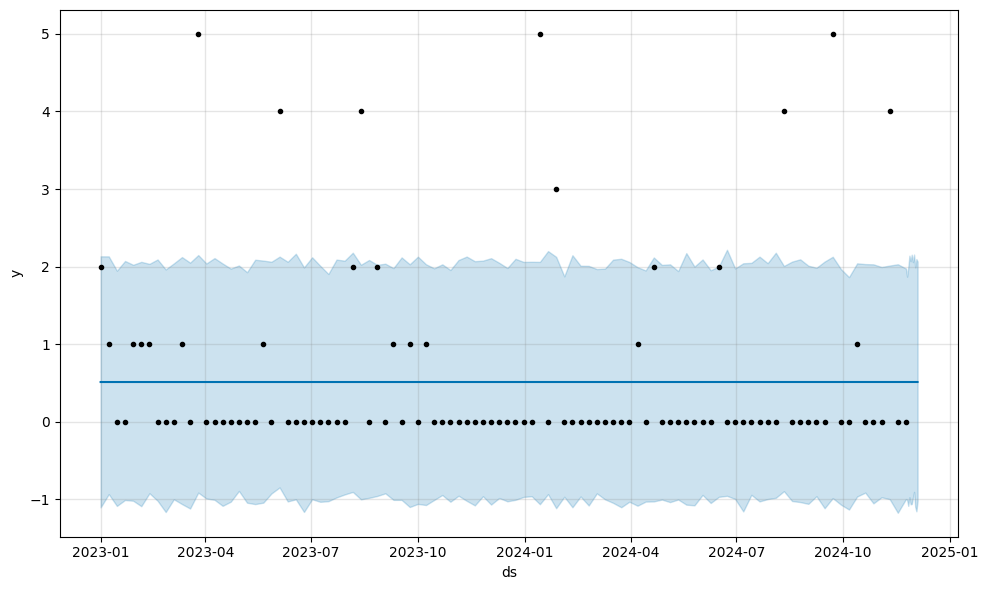

In [104]:
# Plot forecast
fig = model.plot(forecast)
plt.show()

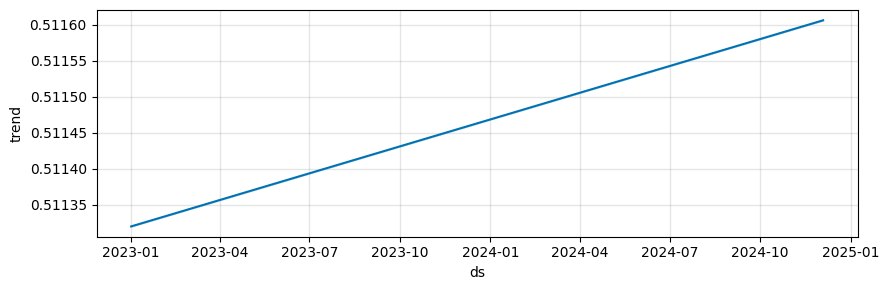

In [105]:
# Plot forecast components (trend, seasonality, effect of temp)
fig2 = model.plot_components(forecast)
plt.show()

### Hyper Parameter tuning product 5

In [110]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
import numpy as np

# Define hyperparameter grid
param_grid = {
    "changepoint_prior_scale": [0.5, 0.55, 0.6, 0.75, 0.8, 0.85],
    "seasonality_prior_scale": [0.0001, 0.001, 0.01, 0.05],
    "seasonality_mode": ["additive", "multiplicative"]
}

# Create all combinations of parameters
grid = list(ParameterGrid(param_grid))

# Split dataset for cross-validation
split_point = int(len(df_prophet) * 0.8)  # 80% train, 20% test
train_df = df_prophet[:split_point]
test_df = df_prophet[split_point:]

best_model = None
best_mse = float("inf")
best_params = None

for params in grid:
    # Initialize and fit model
    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    # model.add_regressor("temp")
    model.fit(train_df)
    
    # Make future dataframe
    future = model.make_future_dataframe(periods=len(test_df))
    # future["temp"] = test_df["temp"].values  # Use actual future temperature values

    # Predict
    forecast = model.predict(future)
    
    # Calculate error (Mean Squared Error)
    mse = np.mean((forecast["yhat"].iloc[-len(test_df):].values - test_df["y"].values) ** 2)
    
    # Save the best model
    if mse < best_mse:
        best_mse = mse
        best_model = model
        best_params = params

print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

03:43:23 - cmdstanpy - INFO - Chain [1] start processing
03:43:24 - cmdstanpy - INFO - Chain [1] done processing
03:43:24 - cmdstanpy - INFO - Chain [1] start processing
03:43:24 - cmdstanpy - INFO - Chain [1] done processing
03:43:24 - cmdstanpy - INFO - Chain [1] start processing
03:43:24 - cmdstanpy - INFO - Chain [1] done processing
03:43:25 - cmdstanpy - INFO - Chain [1] start processing
03:43:25 - cmdstanpy - INFO - Chain [1] done processing
03:43:25 - cmdstanpy - INFO - Chain [1] start processing
03:43:25 - cmdstanpy - INFO - Chain [1] done processing
03:43:26 - cmdstanpy - INFO - Chain [1] start processing
03:43:26 - cmdstanpy - INFO - Chain [1] done processing
03:43:26 - cmdstanpy - INFO - Chain [1] start processing
03:43:26 - cmdstanpy - INFO - Chain [1] done processing
03:43:27 - cmdstanpy - INFO - Chain [1] start processing
03:43:27 - cmdstanpy - INFO - Chain [1] done processing
03:43:27 - cmdstanpy - INFO - Chain [1] start processing
03:43:27 - cmdstanpy - INFO - Chain [1]

Best Parameters: {'changepoint_prior_scale': 0.6, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 0.0001}
Best MSE: 2.6009101969412085


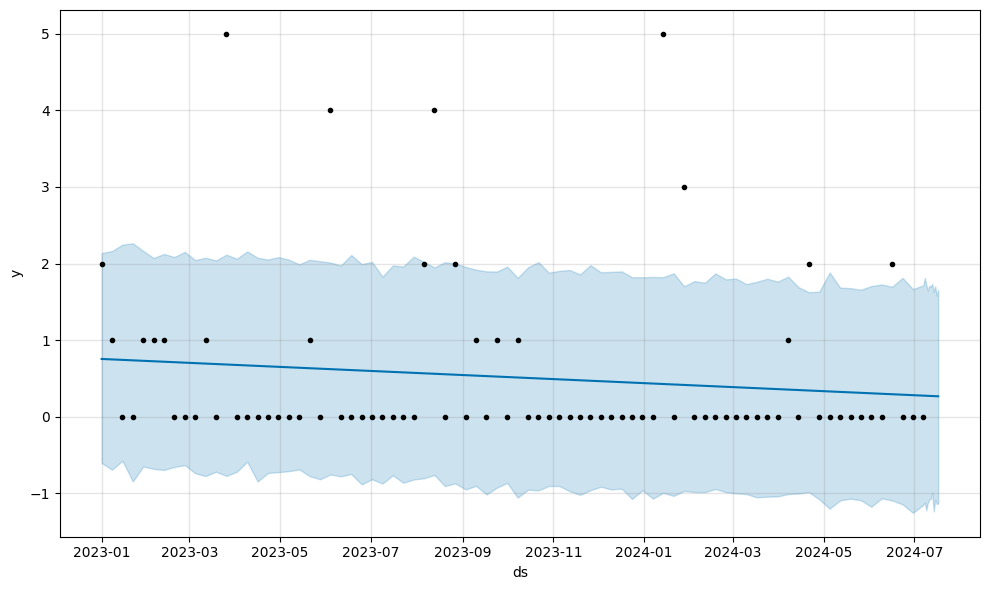

In [111]:
# Predict using the best model
future = best_model.make_future_dataframe(periods=10)
# future["temp"] = df_prophet["temp"].mean()  # Assuming avg temperature

forecast = best_model.predict(future)

# Plot the forecast
best_model.plot(forecast)
plt.show()

In [112]:
# Adjust parameters for small dataset
df_cv = cross_validation(best_model, 
                         horizon="70 days",   # Reduce forecast window
                         period="14 days",    # Reduce step size
                         initial="420 days")  # Ensure training window fits data

# Evaluate performance
df_perf = performance_metrics(df_cv)
df_perf

  0%|          | 0/5 [00:00<?, ?it/s]

03:44:39 - cmdstanpy - INFO - Chain [1] start processing
03:44:39 - cmdstanpy - INFO - Chain [1] done processing
03:44:40 - cmdstanpy - INFO - Chain [1] start processing
03:44:40 - cmdstanpy - INFO - Chain [1] done processing
03:44:40 - cmdstanpy - INFO - Chain [1] start processing
03:44:40 - cmdstanpy - INFO - Chain [1] done processing
03:44:40 - cmdstanpy - INFO - Chain [1] start processing
03:44:40 - cmdstanpy - INFO - Chain [1] done processing
03:44:41 - cmdstanpy - INFO - Chain [1] start processing
03:44:41 - cmdstanpy - INFO - Chain [1] done processing


,horizon,mse,rmse,mae,mdape,smape,coverage
0,7 days,0.749997,0.866024,0.709416,inf,1.698089,0.8
1,14 days,0.130236,0.360883,0.358209,inf,2.000000,1.0
2,21 days,0.744830,0.863035,0.690278,inf,1.685640,0.8
3,28 days,0.122229,0.349612,0.346642,inf,2.000000,1.0
4,35 days,0.676680,0.822606,0.637380,inf,1.648242,0.8
5,42 days,0.114494,0.338370,0.335074,inf,2.000000,1.0
6,49 days,1.105449,1.051403,0.826650,inf,1.745654,0.6
7,56 days,0.107034,0.327160,0.323507,inf,2.000000,1.0
8,63 days,0.684631,0.827424,0.608335,inf,1.903770,0.8
9,70 days,0.099847,0.315986,0.311939,inf,2.000000,1.0
